## import libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, make_scorer

from xgboost import XGBRegressor
import optuna
import plotly

import torch

from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.core.module import LightningModule
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint

from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.models import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

import datetime as dt
from datetime import date

import holidays

import torch
import gc


## define functions

In [36]:
def metric_results(y_train, y_train_pred, y_test, y_test_pred, ndigits=2, target_unit="target"):
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
    
    mean_load_test = y_test.mean()
    mse_test = mean_squared_error(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rel_mae_test  = mae_test / mean_load_test * 100
    rmse_test = root_mean_squared_error(y_test, y_test_pred)
    rel_rmse_test = rmse_test / mean_load_test * 100
    r2_test = r2_score(y_test, y_test_pred) * 100
   
    mean_load_train = y_train.mean()
    mse_train = mean_squared_error(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    rel_mae_train  = mae_train / mean_load_train * 100
    rmse_train = root_mean_squared_error(y_train, y_train_pred)
    rel_rmse_train = rmse_train / mean_load_train * 100
    r2_train = r2_score(y_train, y_train_pred) * 100   


    table = pd.DataFrame(
    [
        [">70%", "0", "0", "0%", "0%"],
        ["%", target_unit, target_unit, "%", "%"],
        [r2_train, rmse_train, mae_train, rel_rmse_train, rel_mae_train],
        [r2_test, rmse_test, mae_test, rel_rmse_test, rel_mae_test],
        [r2_train-r2_test, rmse_train-rmse_test, mae_train-mae_test, rel_rmse_train-rel_rmse_test, rel_mae_train-rel_mae_test]
    ],
    index=["optimal", "unit", "train", "test", "diff"],
    columns=["R²", "RMSE", "MAE", "relRMSE", "relMAE"]
    )

    num_rows = ["train", "test", "diff"]                    # numerische Zeilen nochmal zu float umwandeln
    table.loc[num_rows] = (
        table.loc[num_rows].astype(float).round(ndigits)
    )

    return table


def reset_GPU():
    # delete model and tensors 
    del model
    del data
    del loss

    # run python garbage collector
    gc.collect()

    # clear GPU cache
    torch.cuda.empty_cache()

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(np.abs(y_true - y_pred) / (denom + eps)) * 100.0

## freeze software versions and save as requirements_eda.txt

In [55]:
pip freeze > requirements_ml.txt

Note: you may need to restart the kernel to use updated packages.


## 1. - load datasets

In [6]:
df = pd.read_csv(r"dataset\1 - data first model\load_data_2024-01-01_2026-02-28_cleaned.csv",
                # index_col=0,      # date_time should be a column for TFT model and not the index
                parse_dates=True
                )
df.head(5)

,date_time,load_15min,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,load_1h_ago,load_2h_ago,load_24h_ago,load_168h_ago,rolling_mean_3h,rolling_mean_6h,rolling_mean_12h,rolling_std_3h,rolling_std_6h,rolling_std_12h,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos,weekend,early_shift,late_shift,night_shift,shiftchange_el,shiftchange_ln,shiftchange_ne,date,holiday,bridging_day
0,2024-01-08 00:00:00,10250,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,9880,10420,11480,9480,10385.833333,10275.416667,10497.708333,221.706535,323.271042,359.664380,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
1,2024-01-08 00:15:00,10430,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,10270,10260,10990,9480,10360.833333,10283.750000,10496.875000,194.630575,324.624365,359.776268,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
2,2024-01-08 00:30:00,10720,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,10480,10520,11070,9130,10367.500000,10304.583333,10490.625000,206.094638,336.193257,353.037918,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
3,2024-01-08 00:45:00,10720,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0,10360,10300,11050,9060,10384.166667,10344.583333,10482.083333,226.613742,325.522712,342.027486,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
4,2024-01-08 01:00:00,10750,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0,10250,9880,11150,9130,10411.666667,10399.583333,10475.416667,250.157526,271.268825,333.332358,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0


## 3. - deep learning model TFT (Temporal Fusion Transformer)

### 3.1 - check dataset

In [25]:
# =========================
# Reproduzierbarkeit
# =========================
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
SEED = 42
seed_everything(SEED, workers=True)
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# Optional: echte Feiertage/Brückentage hinterlegen (als date-Objekte)
# Beispiel: HOLIDAYS = {date(2025, 1, 1), date(2025, 4, 18)}

BRIDGING_DAYS = set()
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

# =========================
#  set datatypes
# =========================


df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")
df["load_15min"] = pd.to_numeric(df["load_15min"], errors="coerce")

# select boolean columns
bool_like_cols = [
    "weekend", "early_shift", "late_shift", "night_shift",
    "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
    "holiday", "bridging_day",
]

# convert boolean columns to integer
for c in bool_like_cols:
    if c in df.columns:
        df[c] = df[c].astype(int)

# make sure that the dataset is ordered by time
df = df.sort_values("date_time").reset_index(drop=True)

# =========================
# ensure that cyclical features are numeric and that they exist
# =========================
for c in ["hour_of_day", "minute_of_hour", "month", "season", "weekday"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# one hot encoding for weekday
if "weekday" in df.columns:
    for d in range(7):
        col = f"weekday_{d}"
        if col not in df.columns:
            df[col] = (df["weekday"] == d).astype(int)

# combined time of day
if "time_sin" not in df.columns or "time_cos" not in df.columns:
    if {"hour_of_day", "minute_of_hour"}.issubset(df.columns):
        minutes_since_midnight = df["hour_of_day"] * 60 + df["minute_of_hour"]
        df["time_sin"] = np.sin(2 * np.pi * minutes_since_midnight / (24 * 60))
        df["time_cos"] = np.cos(2 * np.pi * minutes_since_midnight / (24 * 60))

if "hour_sin" not in df.columns and "hour_of_day" in df.columns:
    df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
if "hour_cos" not in df.columns and "hour_of_day" in df.columns:
    df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)

if "minute_sin" not in df.columns and "minute_of_hour" in df.columns:
    df["minute_sin"] = np.sin(2 * np.pi * df["minute_of_hour"] / 60)
if "minute_cos" not in df.columns and "minute_of_hour" in df.columns:
    df["minute_cos"] = np.cos(2 * np.pi * df["minute_of_hour"] / 60)

if "month" in df.columns:
    month0 = df["month"] - 1
    df["month_sin"] = np.sin(2 * np.pi * month0 / 12)
    df["month_cos"] = np.cos(2 * np.pi * month0 / 12)

if "season" in df.columns:
    season0 = df["season"] - 1
    df["season_sin"] = np.sin(2 * np.pi * season0 / 4)
    df["season_cos"] = np.cos(2 * np.pi * season0 / 4)

if "weekday" in df.columns:
    df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

# set columns holiday and bridging day if the exist
df["date"] = df["date_time"].dt.date
# get holidays dates in germany rhineland-palatinate
HOLIDAYS = set(holidays.Germany(years=df["date_time"].dt.year.unique(), prov="RP"))

# get bridging days in germany rhineland-palatinate
BRIDGING_DAYS = set()

for h in HOLIDAYS:
    # day before the holiday (only if holiday is on tuesday -> the day before is monday)
    prev_day = h - dt.timedelta(days=1)     # subtract one day from the holiday date
    if prev_day.weekday() == 0:  # 0 = monday
        BRIDGING_DAYS.add(prev_day)

    # day after the holiday (only if holiday is on thursday -> the day after is friday)
    next_day = h + dt.timedelta(days=1)     # add one day to the holiday date
    if next_day.weekday() == 4:  # 4 = friday
        BRIDGING_DAYS.add(next_day)

# finally set columns holiday and bridging_day new if the exist
if "holiday" in df.columns:
    df["holiday"] = df["date"].isin(HOLIDAYS).astype(int)
if "bridging_day" in df.columns:
    df["bridging_day"] = df["date"].isin(BRIDGING_DAYS).astype(int)

# =========================
# TFT input definitions
# =========================
df["time_idx"] = (df["date_time"] - df["date_time"].min()).dt.total_seconds() // (15 * 60)
df["time_idx"] = df["time_idx"].astype(int)

df["series_id"] = "load"    # we need at least one group/series -> could be plant_1, plant_2 etc.

# define known candidates -> columns/values we already know for the future
known_candidates = [
    "hour", "minute", "month", "weekday", "season",
    "hour_sin", "hour_cos", "minute_sin", "minute_cos",
    "time_sin", "time_cos",
    "month_sin", "month_cos", "weekday_sin", "weekday_cos", "season_sin", "season_cos",
    # one-hot weekdays
    "weekday_0", "weekday_1", "weekday_2", "weekday_3", "weekday_4", "weekday_5", "weekday_6",
    # flags/shifts/holiday etc.
    "weekend", "early_shift", "late_shift", "night_shift",
    "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
    "holiday", "bridging_day",
]
known_reals = [c for c in known_candidates if c in df.columns]          # create list of columns that are in known_candidates and exist in the df

# define observed candidates -> columns/values we don't know for the future
observed_candidates = [
    "load_15min",
    "load_1h_ago", "load_2h_ago", "load_24h_ago", "load_168h_ago",
    "rolling_mean_3h", "rolling_mean_6h", "rolling_mean_12h",
    "rolling_std_3h", "rolling_std_6h", "rolling_std_12h",
]
observed_reals = [c for c in observed_candidates if c in df.columns]    # create list of columns that are in observed_candidates and exist in the df

Seed set to 42


### 3.2 - data split

In [ ]:
# =========================
# 5) Train/Val-Split + DataSets
# =========================
STEPS_PER_HOUR = 4  # 4 values each hour
HORIZON_H = 24 * 1  # how far into the future to predict -> 24 * 1 -> 1 day
max_prediction_length = HORIZON_H * STEPS_PER_HOUR   # 96 (24h) -> predict 96 steps into the future -> 1 day and for each hour 4 values to predict

# use 10 days of context for training
ENCODER_DAYS = 10  # <— if you get an "out of memory" error, decrease to 8 or even more -> should be (5 * (HORIZON_H / 24))
max_encoder_length = ENCODER_DAYS * 24 * STEPS_PER_HOUR  # 10 * 24 * 4 = 960

val_days = 60   # save last 60 days for validation/forecast
cutoff_time = df["date_time"].max() - pd.Timedelta(days=val_days)        # calculate the timestamp thas is exactly 60 days before the last timestamp
cutoff_idx = df.loc[df["date_time"] <= cutoff_time, "time_idx"].max()    # convert this timestamp to time_idx -> tft is working with time_idx instead timestamps

# time ---------------------------------------------------------------->

# train:      |------------------------------| cutoff_time                     -> 0 to cutoff_time
# validation:                                 |--------(60 days)-------|       -> cutoff_time + 1 to max

# define training dataset
training = TimeSeriesDataSet(
    df[df["time_idx"] <= cutoff_idx],               # without the last 60 days -> these are for validation
    time_idx="time_idx",                            # 
    target="load_15min",                            # define the target column
    group_ids=["series_id"],                        # define group_ids column -> you need at least one -> could be plant_1, plant_2 or meter_1, meter_2etc.
    max_encoder_length=max_encoder_length,          # define length of historical data to train for the prediction
    max_prediction_length=max_prediction_length,    # define how far into the future to predict
    time_varying_known_reals=known_reals,           # define columns that are known in the future
    time_varying_unknown_reals=observed_reals,      # define columns that are not known in the future
    target_normalizer=GroupNormalizer(groups=["series_id"]),    # 
    add_relative_time_idx=True,                     # 
    add_target_scales=True,                         # 
    add_encoder_length=True,                        # 
    allow_missing_timesteps=True,                   # 
)

# define validation dataset
validation = TimeSeriesDataSet.from_dataset(
    training,                                       # make sure that scaling and encoding is identical to the training dataset
    df,                                             # define df to take for validation
    min_prediction_idx=cutoff_idx + 1,              # set first time_idx to take for validation
    stop_randomization=True                         # 
)

### 3.3 - create dataloader for train and validation

In [27]:
# create pyTorch-dataloader for train and validation
train_loader = training.to_dataloader(train=True,           # True = train dataloader -> shuffle, don't learn order of data
                                      batch_size=64,        # bigger is better -> depends on your VRAM
                                      num_workers=0)        # include x CPU cores -> multiprocessing (sometimes probems under Windows)
val_loader   = validation.to_dataloader(train=False,        # False = validation dataloader
                                        batch_size=64,      # bigger is better -> depends on your VRAM
                                        num_workers=0)      # include x CPU cores -> multiprocessing (sometimes probems under Windows)

### 3.4 - create TFT model

In [28]:
tft_model = TemporalFusionTransformer.from_dataset(
    training,
    hidden_size=64,
    lstm_layers=2,
    attention_head_size=4,
    dropout=0.3,                       # etwas mehr Regularisierung
    loss=QuantileLoss(),
    learning_rate=5e-4,                # vorsichtiger als 1e-3
    optimizer="adamw",                 # AdamW verwenden
    weight_decay=1e-4,                 # <-- HIER setzen (kein optimizer_params!)
    reduce_on_plateau_patience=4,
)

# check if the tft_model is an instance of LightningModule, raise an error if not
assert isinstance(tft_model, LightningModule), f"not a LightningModule: {type(tft_model)}"

### 3.5 - train model

In [ ]:
#################################################
# define callbacks
#################################################

# activate output to see the progress during training
lr_monitor = LearningRateMonitor(logging_interval="epoch")

# activate early stopping -> stop training if the val_loss no longer decreases
early_stop = EarlyStopping(
    monitor="val_loss",
    min_delta=0.0,
    patience=6,
    mode="min",
)

# save only the best checkpoint
ckpt = ModelCheckpoint(
    monitor="val_loss", # what value to compare while training
    mode="min",         # in which direction should the value go? -> min = decrease
    save_top_k=1,       # save only one checkpoint -> best one
    filename="tft-best-{epoch:02d}-{val_loss:.4f}"
)

#################################################
# define trainer
#################################################
trainer = Trainer(
    max_epochs=50,                  # how many epochs to train
    accelerator="gpu",              # activate GPU for training
    devices=1,                      # number of GPUs used for training
    precision="bf16-mixed",         # mixed precision is usually more stable
    gradient_clip_val=0.1,
    callbacks=[early_stop, lr_monitor, ckpt],
    enable_checkpointing=True,      # enable saving of checkpoints
)

#################################################
# train model
#################################################
trainer.fit(model=tft_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

### 3.6 - load trained tft model

In [29]:
# Optional: bestes Modell laden (für Auswertung/Forecast)
# best_path = ckpt.best_model_path
best_path = r"lightning_logs\version_5\checkpoints\tft-best-epoch=01-val_loss=461.9054.ckpt"
if best_path:
    tft_model = TemporalFusionTransformer.load_from_checkpoint(best_path, map_location="cuda")

### 3.7 - evaluation of trained model

In [30]:
torch.set_grad_enabled(False)

y_true_list = []
for batch in val_loader:
    # In pytorch-forecasting ist batch meist (x, y)
    # y ist i.d.R. ein Tuple: (decoder_target, weight)
    x_b, y_b = batch
    yt = y_b[0] if isinstance(y_b, (list, tuple)) and len(y_b) >= 1 else y_b
    yt = yt.detach().cpu().numpy()
    if yt.ndim == 3 and yt.shape[-1] == 1:
        yt = yt.squeeze(-1)  # [B, dec_len, 1] -> [B, dec_len]
    y_true_list.append(yt.reshape(-1))

y_true = np.concatenate(y_true_list, axis=0)

In [ ]:
# find index of of 0.5 quantile
quants = list(getattr(tft_model.loss, "quantiles", [])) # -> [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
median_idx = quants.index(0.5)                          #       0     1    2    3     4    5     6  -> 3 = 0.5


pred_iter = tft_model.predict(
    val_loader,
    mode="prediction",
    batch_size=64,                          # has to be the same like batch_size for val_loader
    num_workers=0,
    trainer_kwargs={
        "accelerator": "gpu",   
        "devices": 1,
        "precision": "bf16-mixed",  
    },
)

y_pred_list = []
for out in pred_iter:

    if torch.is_tensor(out):
        t = out
    elif isinstance(out, (list, tuple)) and len(out) >= 1 and torch.is_tensor(out[0]):
        t = out[0]
    else:
        raise TypeError(f"unexpected prediction type: {type(out)}")

    # t is a Tensor (bfloat16) -> first convert to float32, then send to CPUand convert to numpy
    arr = t.detach().to(torch.float32).cpu().numpy()

    # if quantile: [B, dec_len, n_q] -> median (0.5) = index 1
    if arr.ndim == 3:
        arr = arr[:, :, median_idx]

    y_pred_list.append(arr.reshape(-1))

y_pred = np.concatenate(y_pred_list, axis=0)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [32]:
y_pred.shape

(543840,)

In [33]:
y_pred

array([11904., 11904., 11904., ..., 11392., 11328., 11328.],
      shape=(543840,), dtype=float32)

In [34]:
y_true.shape

(543840,)

In [15]:
y_true

array([12280, 12350, 12100, ..., 11090, 11160, 11000], shape=(543840,))

### 3.8 - plot | true vs predicted

In [37]:
mae  = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred)
s    = smape(y_true, y_pred)
print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | SMAPE: {s:.2f}%")

MAE: 828.7491 | RMSE: 1090422.1250 | SMAPE: 7.21%


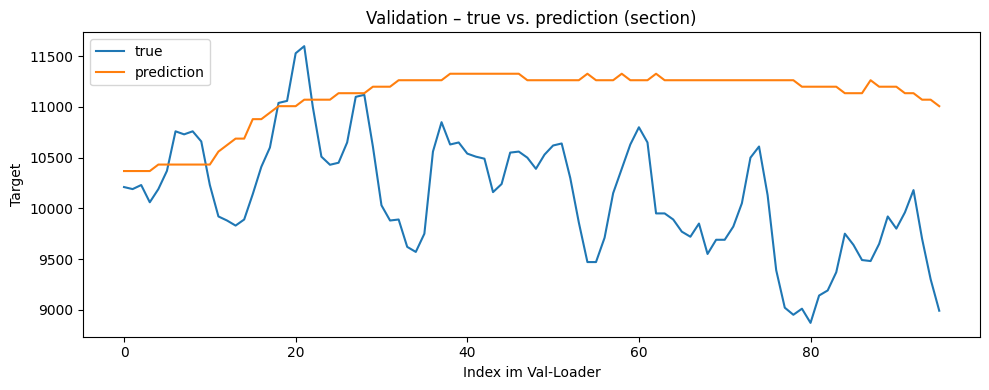

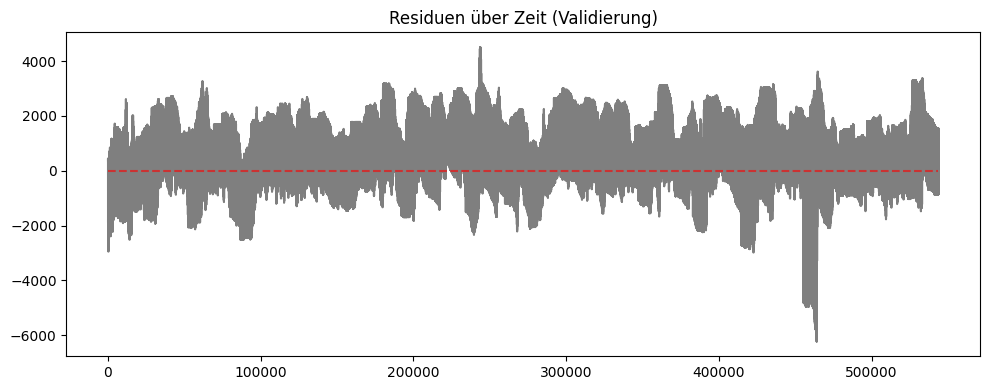

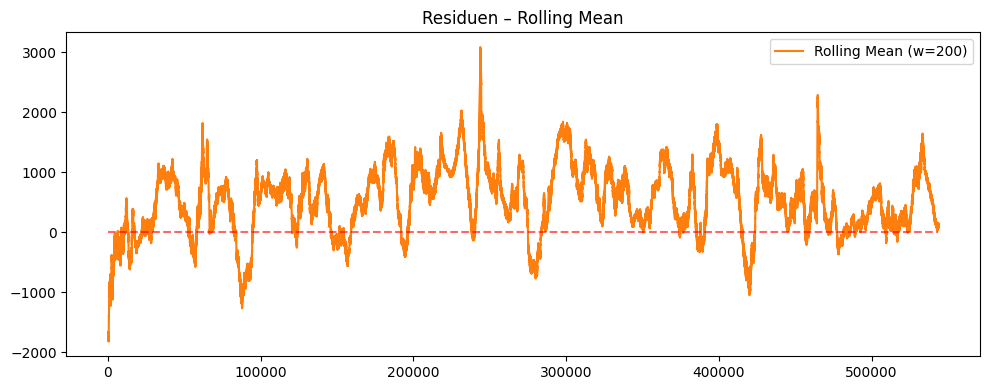

In [41]:
# true vs. prediction (section)
N = min(10, len(y_true)/96)
plt.figure(figsize=(10,4))
plt.plot(y_true[(N-1)*96:N*96], label="true")
plt.plot(y_pred[(N-1)*96:N*96], label="prediction")
# plt.plot(y_true[0:N*96], label="true")
# plt.plot(y_pred[0:N*96], label="prediction")
plt.title("Validation – true vs. prediction (section)")
plt.xlabel("Index im Val-Loader")
plt.ylabel("Target")
plt.legend()
plt.tight_layout()
plt.show()

# Residuen & Rolling-Mittel
residuals = y_true - y_pred

plt.figure(figsize=(10, 4))
plt.plot(residuals, color="tab:gray")
plt.hlines(0, 0, len(residuals), colors="r", linestyles="dashed", alpha=0.6)
plt.title("Residuen über Zeit (Validierung)")
plt.tight_layout()
plt.show()

window = 200
roll_mean = pd.Series(residuals).rolling(window).mean()
plt.figure(figsize=(10, 4))
plt.plot(roll_mean, color="tab:orange", label=f"Rolling Mean (w={window})")
plt.hlines(0, 0, len(roll_mean), colors="r", linestyles="dashed", alpha=0.6)
plt.title("Residuen – Rolling Mean")
plt.legend()
plt.tight_layout()
plt.show()